# Daily IPCA vs GIPCA: S&P 500 (Sharadar) with FF5 Macro

Compare four estimators on **daily** S&P 500 returns from the Sharadar database:

| Model | Estimator | Predictive signal |
|-------|-----------|-------------------|
| **IPCA** | ALS | Mean factor $\hat{\lambda}$ |
| **IPCA** | Grassmannian (CG) | Mean factor $\hat{\lambda}$ |
| **GIPCA** | ALS | Macro-predicted $\hat{\Delta}' m_{t-1}$ (lagged) |
| **GIPCA** | Grassmannian (CG) | Macro-predicted $\hat{\Delta}' m_{t-1}$ (lagged) |

**IPCA model:** $x_{i,t+1} = \beta_{i,t}' f_{t+1} + \varepsilon_{i,t+1}$, $\beta_{i,t} = \Gamma' z_{i,t}$

**GIPCA extension:** $f_t = f^0_t + \Delta' m_t$ (macro-decomposed factors)

**Data:** Sharadar daily prices (2015–2018), S&P 500 constituents (point-in-time), 20 firm characteristics, 5 Fama-French factors as daily macro variables.  
**Characteristics:** 20 (mvel1, bm, ep, sp, roaq, roeq, gma, operprof, agr, sgr, lev, currat, chcsho, cfp, depr, dy, mom1m, mom6m, retvol, turn)  
**Macro variables:** Mkt-RF, SMB, HML, RMW, CMA (daily FF5, in decimal).  
**Z-scoring:** training-period statistics only (no look-ahead bias).  
**Train:** 2015–2016, **Test:** 2017–2018, **K = 5** factors.

In [1]:
import sys, os, time
os.chdir(os.path.join(os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.generate.daily_sharadar import build_daily_panel, CHAR_NAMES, MACRO_NAMES
from src.models.als_ipca import ALSIPCA
from src.models.grassmanian_ipca import GrassmannManifoldIPCAEstimator
from src.models.als_gipca import HardGIPCA
from src.models.grassmanian_gipca import GrassmannManifoldGIPCAEstimator

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Load & Prepare Data

In [2]:
data = build_daily_panel('data', start_date='2015-01-01', end_date='2018-12-31', verbose=True)

1/10  Loading S&P 500 membership …
       1069 unique tickers ever in S&P 500
2/10  Loading daily returns (SEP) …


       799,539 return observations loaded
3/10  Filtering to S&P 500 members …


       590,935 after S&P 500 filter
4/10  Loading daily valuations (DAILY) …


       792,013 valuation observations
5/10  Loading quarterly fundamentals (SF1) …


       68,586 quarterly observations
6/10  Merging data sources …
7/10  Forward-filling quarterly fundamentals …


8/10  Computing rolling characteristics …


9/10  Pivoting to balanced arrays …


10/10 Rank-transforming characteristics …



Panel summary:
  T = 1006 trading days
  N = 611 stocks
  L = 20 characteristics
  R = 5 macro factors
  Dates: 2015-01-02 — 2018-12-31
  Non-zero returns: 82.2%
  Characteristic coverage (non-zero %):
         mvel1: 81.6%
            bm: 81.6%
            ep: 81.6%
            sp: 81.6%
          roaq: 81.5%
          roeq: 81.5%
           gma: 81.5%
      operprof: 81.5%
           agr: 81.3%
           sgr: 80.9%
           lev: 81.6%
        currat: 67.5%
        chcsho: 81.3%
           cfp: 81.6%
          depr: 81.4%
            dy: 81.5%
         mom1m: 82.0%
         mom6m: 80.7%
        retvol: 82.0%
          turn: 81.3%


In [3]:
returns_arr = data['returns_arr']   # (T, N) excess returns
chars_arr   = data['chars_arr']     # (T, N, L)
macro_arr   = data['macro_arr']     # (T, R)
dates       = data['dates']
tickers     = data['tickers']
char_names  = data['char_names']
macro_names = data['macro_names']
rf          = data['rf']

T, N = returns_arr.shape
L = len(char_names)
R = len(macro_names)

print(f"Panel: T={T}, N={N}, L={L}, R={R}")
print(f"Dates: {pd.Timestamp(dates[0]).date()} — {pd.Timestamp(dates[-1]).date()}")
print(f"Characteristics: {', '.join(char_names)}")
print(f"Macro: {', '.join(macro_names)}")
print(f"Non-zero returns: {(returns_arr != 0).sum():,} / {T*N:,} ({(returns_arr != 0).mean():.1%})")

Panel: T=1006, N=611, L=20, R=5
Dates: 2015-01-02 — 2018-12-31
Characteristics: mvel1, bm, ep, sp, roaq, roeq, gma, operprof, agr, sgr, lev, currat, chcsho, cfp, depr, dy, mom1m, mom6m, retvol, turn
Macro: Mkt-RF, SMB, HML, RMW, CMA
Non-zero returns: 505,350 / 614,666 (82.2%)


In [4]:
# --- Train / test split at 2016-12-31 ---
split_date = pd.Timestamp('2016-12-31')
split_idx = np.searchsorted(dates, np.datetime64(split_date), side='right')

train_rets = returns_arr[:split_idx]
train_Z    = chars_arr[:split_idx]
test_rets  = returns_arr[split_idx:]
test_Z     = chars_arr[split_idx:]

T_train = split_idx
T_test  = T - split_idx
K = 5  # number of factors

# --- Z-score macro using TRAINING stats only ---
train_macro_raw = macro_arr[:split_idx]
test_macro_raw  = macro_arr[split_idx:]

macro_means = train_macro_raw.mean(axis=0)
macro_stds  = train_macro_raw.std(axis=0)

train_macro = (train_macro_raw - macro_means) / macro_stds
test_macro  = (test_macro_raw  - macro_means) / macro_stds

# --- Lagged training data for GIPCA ---
# Pair returns[t] with macro[t-1] so Delta regresses f_t on m_{t-1}
train_rets_lag  = returns_arr[1:split_idx]   # (T_train-1, N)
train_Z_lag     = chars_arr[1:split_idx]     # (T_train-1, N, L)
train_macro_lag = train_macro[:-1]           # (T_train-1, R)
T_train_lag = T_train - 1

# OOS lagged macro
test_macro_lag = np.vstack([train_macro[-1:], test_macro[:-1]])  # (T_test, R)

print(f"K = {K} factors, R = {R} macro predictors")
print(f"Train: {T_train} days ({pd.Timestamp(dates[0]).date()} — {pd.Timestamp(dates[split_idx-1]).date()})")
print(f"Test:  {T_test} days ({pd.Timestamp(dates[split_idx]).date()} — {pd.Timestamp(dates[-1]).date()})")
print(f"GIPCA lagged train: {T_train_lag} days")
print(f"Macro z-scored using training stats only (no look-ahead bias)")

K = 5 factors, R = 5 macro predictors
Train: 504 days (2015-01-02 — 2016-12-30)
Test:  502 days (2017-01-03 — 2018-12-31)
GIPCA lagged train: 503 days
Macro z-scored using training stats only (no look-ahead bias)


## 2. Fit All Four Models

In [5]:
# ============================
# ALS IPCA
# ============================
als_ipca = ALSIPCA(num_assets=N, num_fact=K, num_charact=L, win_len=T_train)
t0 = time.time()
Gamma_als_ipca, hist_als_ipca = als_ipca.fit(
    [train_rets, train_Z], max_iter=500, tol=1e-6, verbose=True,
)
time_als_ipca = time.time() - t0
f_als_ipca = als_ipca.factors.values.T   # (T_train, K)
lam_als_ipca = als_ipca.Lambda.values     # (K,)
print(f"ALS IPCA: obj={hist_als_ipca[-1]:.6f}, iters={als_ipca.n_iterations}, time={time_als_ipca:.1f}s\n")

Iteration    0: Objective = 0.156090
Iteration    1: Objective = 0.152020, Gamma change = 0.71825635, Factor change = 0.00000000


Iteration    2: Objective = 0.151657, Gamma change = 0.91897050, Factor change = 0.05494558


Iteration    3: Objective = 0.151574, Gamma change = 0.06249299, Factor change = 0.06557302


Iteration    4: Objective = 0.151540, Gamma change = 0.04197098, Factor change = 0.00427217
Iteration    5: Objective = 0.151520, Gamma change = 0.03138536, Factor change = 0.00258345


Iteration    6: Objective = 0.151506, Gamma change = 0.02451373, Factor change = 0.00187224


...

Iteration  118: Objective = 0.151421, Gamma change = 0.00000140, Factor change = 0.00000012


Iteration  119: Objective = 0.151421, Gamma change = 0.00000128, Factor change = 0.00000011


Iteration  120: Objective = 0.151421, Gamma change = 0.00000117, Factor change = 0.00000010


Iteration  121: Objective = 0.151421, Gamma change = 0.00000108, Factor change = 0.00000009
Iteration  122: Objective = 0.151421, Gamma change = 0.00000099, Factor change = 0.00000009

Converged after 122 iterations
Initial objective: 0.156090
Final objective:   0.151421
Reduction:         2.99%


ALS IPCA: obj=0.151421, iters=122, time=49.8s



In [6]:
# ============================
# Grassmannian IPCA
# ============================
grass_ipca = GrassmannManifoldIPCAEstimator(
    num_assets=N, num_fact=K, num_charact=L, win_len=T_train,
)
t0 = time.time()
Gamma_grass_ipca, f_grass_ipca, hist_grass_ipca = grass_ipca.fit(
    [train_rets, train_Z], optimizer="ConjugateGradient",
    max_iterations=300, verbosity=2,
)
time_grass_ipca = time.time() - t0
lam_grass_ipca = f_grass_ipca.mean(axis=0)  # (K,)
print(f"\nGrassmannian IPCA: obj={hist_grass_ipca[-1]:.6f}, time={time_grass_ipca:.1f}s")

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    


  1          +1.6055504119715958e-01    1.95664555e-02    
  2          +1.5726319520962237e-01    8.54636441e-03    


  3          +1.5598048239695500e-01    4.42349917e-03    
  4          +1.5517569700169304e-01    3.21599071e-03    


  5          +1.5426081944608450e-01    2.84571865e-03    
  6          +1.5309637798229739e-01    3.61589547e-03    


  7          +1.5248335708918398e-01    1.71913363e-03    
  8          +1.5225031463854605e-01    1.36132031e-03    


...

 60          +1.5142076591418732e-01    4.63592992e-06    
 61          +1.5142075895257945e-01    4.44394270e-06    


 62          +1.5142075715957701e-01    3.00089108e-06    


 63          +1.5142075631330115e-01    1.88093011e-06    
 64          +1.5142075588927284e-01    1.28574402e-06    


 65          +1.5142075564044033e-01    1.20640271e-06    
 66          +1.5142075534693802e-01    1.49714900e-06    


 67          +1.5142075497246654e-01    1.76793296e-06    
 68          +1.5142075476780864e-01    9.95317211e-07    
Terminated - min grad norm reached after 68 iterations, 13.16 seconds.


Grassmannian IPCA: obj=0.151421, time=13.4s


In [7]:
# ============================
# ALS GIPCA (alpha > 0, lagged macro)
# ============================
ALPHA = 0.1

als_gipca = HardGIPCA(
    num_assets=N, num_fact=K, num_charact=L,
    num_macro=R, win_len=T_train_lag, alpha=ALPHA,
)
t0 = time.time()
Gamma_als_gipca, hist_als_gipca = als_gipca.fit(
    [train_rets_lag, train_Z_lag, train_macro_lag],
    max_iter=500, min_iter=100, tol=1e-6, verbose=True,
)
time_als_gipca = time.time() - t0
f_als_gipca = als_gipca.factors.values.T   # (T_train_lag, K)
Delta_als_gipca = als_gipca.Delta           # (K, R)
print(f"\nALS GIPCA (alpha={ALPHA}): obj={hist_als_gipca[-1]:.6f}, iters={als_gipca.n_iterations}, time={time_als_gipca:.1f}s")
print(f"  Trained on lagged data: returns[1:] ~ macro[:-1], T={T_train_lag}")

Init IPCA profiled loss: 0.155279
Iteration    0: Objective = 0.155305 (alpha=0.1)


Iteration   10: Objective = 0.151777, Obj change = 3.41e-05, Param change = 1.34e-02


Iteration   20: Objective = 0.151732, Obj change = 2.27e-05, Param change = 1.15e-02


Iteration   30: Objective = 0.151709, Obj change = 1.08e-05, Param change = 1.24e-02


Iteration   40: Objective = 0.151696, Obj change = 7.06e-06, Param change = 1.23e-02


...

Iteration   60: Objective = 0.151685, Obj change = 1.08e-06, Param change = 5.11e-03


Iteration   70: Objective = 0.151685, Obj change = 2.49e-07, Param change = 2.38e-03


Iteration   80: Objective = 0.151684, Obj change = 5.38e-08, Param change = 1.05e-03


Iteration   90: Objective = 0.151684, Obj change = 1.23e-08, Param change = 4.60e-04


Iteration  100: Objective = 0.151684, Obj change = 3.24e-09, Param change = 2.08e-04

Converged after 100 iterations
Initial objective: 0.155305
Final objective:   0.151684
Reduction:         2.33%
Identification check: || f0^T @ mu || = 2.28e-11

ALS GIPCA (alpha=0.1): obj=0.151684, iters=100, time=20.4s
  Trained on lagged data: returns[1:] ~ macro[:-1], T=503


In [8]:
# ============================
# Grassmannian GIPCA (lagged macro)
# ============================
grass_gipca = GrassmannManifoldGIPCAEstimator(
    num_assets=N, num_fact=K, num_charact=L,
    num_macro=R, win_len=T_train_lag,
)
t0 = time.time()
Gamma_grass_gipca, Delta_grass_gipca, f0_grass_gipca, f_grass_gipca, hist_grass_gipca = grass_gipca.fit(
    [train_rets_lag, train_Z_lag, train_macro_lag],
    optimizer="ConjugateGradient",
    max_iterations=300, verbosity=2,
)
time_grass_gipca = time.time() - t0
print(f"\nGrassmannian GIPCA: obj={hist_grass_gipca[-1]:.6f}, time={time_grass_gipca:.1f}s")
print(f"  Trained on lagged data: returns[1:] ~ macro[:-1], T={T_train_lag}")

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    


  1          +1.5801412322366123e-01    7.21757432e-03    
  2          +1.5584856418894844e-01    4.01570582e-03    


  3          +1.5480513993992001e-01    3.54613468e-03    


  4          +1.5349056895983873e-01    2.17844761e-03    
  5          +1.5264261100714135e-01    1.40361151e-03    


  6          +1.5243029892928284e-01    1.20667829e-03    
  7          +1.5210508545039597e-01    1.08749555e-03    


...

 73          +1.5164944656346760e-01    3.21629739e-06    


 74          +1.5164944532031935e-01    2.56014317e-06    
 75          +1.5164944435999300e-01    1.88081197e-06    


 76          +1.5164944389578575e-01    1.19654212e-06    
 77          +1.5164944367388775e-01    1.03770741e-06    


 78          +1.5164944339673436e-01    1.70628117e-06    


 79          +1.5164944304987063e-01    1.19825703e-06    
 80          +1.5164944286267759e-01    7.53069787e-07    
Terminated - min grad norm reached after 80 iterations, 15.52 seconds.


Grassmannian GIPCA: obj=0.151649, time=15.8s
  Trained on lagged data: returns[1:] ~ macro[:-1], T=503


## 3. R² Evaluation

In [9]:
def ols_factors(rets_filled, Z, Gamma):
    """Re-estimate factors via cross-sectional OLS."""
    T_e, N_e = rets_filled.shape
    K_e = Gamma.shape[1]
    factors = np.zeros((T_e, K_e))
    for t in range(T_e):
        loadings_t = Z[t] @ Gamma
        factors[t], *_ = np.linalg.lstsq(loadings_t, rets_filled[t], rcond=None)
    return factors


def compute_r2(rets_raw, fitted):
    """R2 = 1 - SS_res / SS_tot (denominator = sum x^2, excess returns)."""
    mask = rets_raw != 0  # non-missing entries (NaN already filled with 0)
    ss_tot = np.sum(rets_raw[mask] ** 2)
    ss_res = np.sum((rets_raw[mask] - fitted[mask]) ** 2)
    return 1 - ss_res / ss_tot


def fitted_total(Z, Gamma, factors):
    """x_hat_t = Z_t @ Gamma @ f_t"""
    T_e = Z.shape[0]
    out = np.zeros((T_e, Z.shape[1]))
    for t in range(T_e):
        out[t] = Z[t] @ Gamma @ factors[t]
    return out


def fitted_pred_ipca(Z, Gamma, lam):
    """x_hat_t = Z_t @ Gamma @ lambda (mean factor)"""
    T_e = Z.shape[0]
    out = np.zeros((T_e, Z.shape[1]))
    for t in range(T_e):
        out[t] = Z[t] @ Gamma @ lam
    return out


def fitted_pred_gipca(Z, Gamma, Delta, macro_lag):
    """x_hat_t = Z_t @ Gamma @ Delta' m_{t-1} (lagged macro)"""
    T_e = Z.shape[0]
    out = np.zeros((T_e, Z.shape[1]))
    for t in range(T_e):
        out[t] = Z[t] @ Gamma @ (Delta @ macro_lag[t])
    return out


# --- Re-estimate OOS factors ---
f_oos_als_ipca   = ols_factors(test_rets, test_Z, Gamma_als_ipca)
f_oos_grass_ipca = ols_factors(test_rets, test_Z, Gamma_grass_ipca)
f_oos_als_gipca  = ols_factors(test_rets, test_Z, Gamma_als_gipca)
f_oos_grass_gipca = ols_factors(test_rets, test_Z, Gamma_grass_gipca)

print(f"OOS factors re-estimated: T_test={T_test}")

OOS factors re-estimated: T_test=502


In [10]:
# ---------- Compute all R² ----------
models = ['ALS IPCA', 'Grass IPCA', 'ALS GIPCA', 'Grass GIPCA']
results = {}

results['ALS IPCA'] = {
    'is_total':  compute_r2(train_rets, fitted_total(train_Z, Gamma_als_ipca, f_als_ipca)),
    'oos_total': compute_r2(test_rets, fitted_total(test_Z, Gamma_als_ipca, f_oos_als_ipca)),
    'is_pred':   compute_r2(train_rets, fitted_pred_ipca(train_Z, Gamma_als_ipca, lam_als_ipca)),
    'oos_pred':  compute_r2(test_rets, fitted_pred_ipca(test_Z, Gamma_als_ipca, lam_als_ipca)),
    'obj': hist_als_ipca[-1], 'iters': als_ipca.n_iterations,
    'time': time_als_ipca, 'params': L * K,
}

results['Grass IPCA'] = {
    'is_total':  compute_r2(train_rets, fitted_total(train_Z, Gamma_grass_ipca, f_grass_ipca)),
    'oos_total': compute_r2(test_rets, fitted_total(test_Z, Gamma_grass_ipca, f_oos_grass_ipca)),
    'is_pred':   compute_r2(train_rets, fitted_pred_ipca(train_Z, Gamma_grass_ipca, lam_grass_ipca)),
    'oos_pred':  compute_r2(test_rets, fitted_pred_ipca(test_Z, Gamma_grass_ipca, lam_grass_ipca)),
    'obj': hist_grass_ipca[-1], 'iters': len(hist_grass_ipca),
    'time': time_grass_ipca, 'params': L * K,
}

results['ALS GIPCA'] = {
    'is_total':  compute_r2(train_rets_lag, fitted_total(train_Z_lag, Gamma_als_gipca, f_als_gipca)),
    'oos_total': compute_r2(test_rets, fitted_total(test_Z, Gamma_als_gipca, f_oos_als_gipca)),
    'is_pred':   compute_r2(train_rets_lag, fitted_pred_gipca(train_Z_lag, Gamma_als_gipca, Delta_als_gipca, train_macro_lag)),
    'oos_pred':  compute_r2(test_rets, fitted_pred_gipca(test_Z, Gamma_als_gipca, Delta_als_gipca, test_macro_lag)),
    'obj': hist_als_gipca[-1], 'iters': als_gipca.n_iterations,
    'time': time_als_gipca, 'params': L * K + K * R,
}

results['Grass GIPCA'] = {
    'is_total':  compute_r2(train_rets_lag, fitted_total(train_Z_lag, Gamma_grass_gipca, f_grass_gipca)),
    'oos_total': compute_r2(test_rets, fitted_total(test_Z, Gamma_grass_gipca, f_oos_grass_gipca)),
    'is_pred':   compute_r2(train_rets_lag, fitted_pred_gipca(train_Z_lag, Gamma_grass_gipca, Delta_grass_gipca, train_macro_lag)),
    'oos_pred':  compute_r2(test_rets, fitted_pred_gipca(test_Z, Gamma_grass_gipca, Delta_grass_gipca, test_macro_lag)),
    'obj': hist_grass_gipca[-1], 'iters': len(hist_grass_gipca),
    'time': time_grass_gipca, 'params': L * K + K * R,
}

# --- Print comparison table ---
sup2 = chr(178)
header = f"{'':28s}" + "".join(f"{m:>14s}" for m in models)
print(header)
print("=" * (28 + 14 * 4))

rows = [
    ('Final objective', 'obj', '.4f', 1),
    ('IS Total R' + sup2 + ' (%)', 'is_total', '.2f', 100),
    ('IS Predictive R' + sup2 + ' (%)', 'is_pred', '.2f', 100),
    ('OOS Total R' + sup2 + ' (%)', 'oos_total', '.2f', 100),
    ('OOS Predictive R' + sup2 + ' (%)', 'oos_pred', '.2f', 100),
]

for label, key, fmt, scale in rows:
    vals = "".join(f"{results[m][key]*scale:14{fmt}}" for m in models)
    print(f"{label:28s}{vals}")
    if key == 'is_pred':
        print("-" * (28 + 14 * 4))

print("=" * (28 + 14 * 4))
iter_vals = "".join(f"{results[m]['iters']:14d}" for m in models)
print(f"{'Iterations':28s}{iter_vals}")
time_vals = "".join(f"{results[m]['time']:14.1f}" for m in models)
print(f"{'Wall time (s)':28s}{time_vals}")
par_vals = "".join(f"{results[m]['params']:14d}" for m in models)
print(f"{'Parameters':28s}{par_vals}")
print(f"\nNote: GIPCA trained on lagged data (returns[1:] ~ macro[:-1]), alpha={ALPHA}")
print(f"      Daily frequency — expect lower R\u00b2 than monthly (5-15% total, 0.01-0.5% pred)")

                                  ALS IPCA    Grass IPCA     ALS GIPCA   Grass GIPCA
Final objective                     0.1514        0.1514        0.1517        0.1516
IS Total R² (%)                      10.97         10.97         10.97         10.97
IS Predictive R² (%)                  0.00          0.00          0.13          0.13
------------------------------------------------------------------------------------
OOS Total R² (%)                      8.57          8.57          8.57          8.56
OOS Predictive R² (%)                -0.00         -0.00         -0.07         -0.07
Iterations                             122            68           100            80
Wall time (s)                         49.8          13.4          20.4          15.8
Parameters                             100           100           125           125

Note: GIPCA trained on lagged data (returns[1:] ~ macro[:-1]), alpha=0.1
      Daily frequency — expect lower R² than monthly (5-15% total, 0.01-0.5%

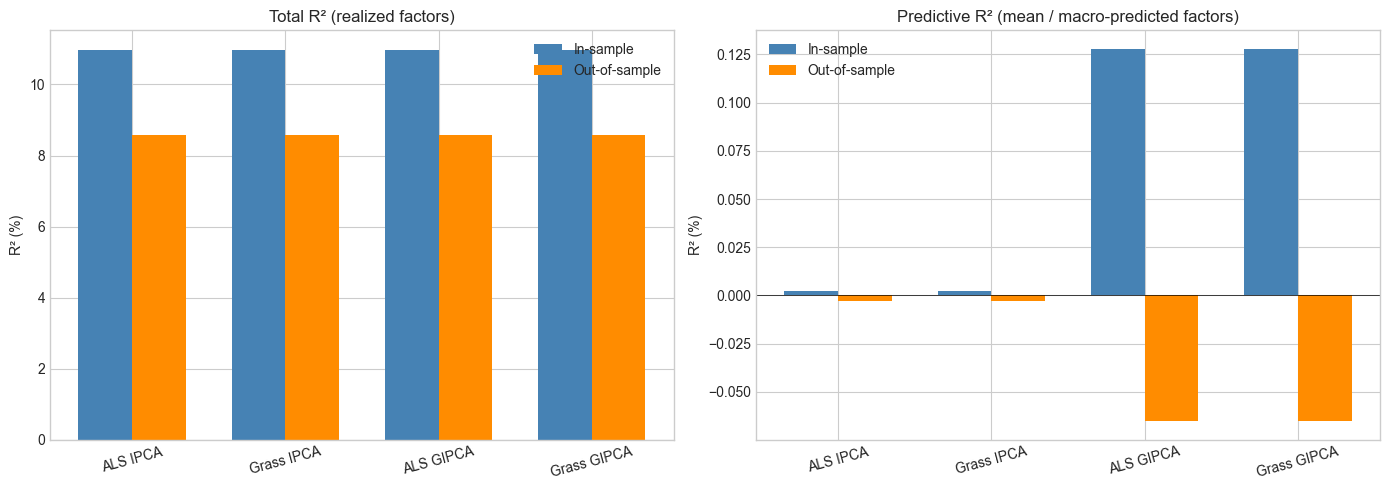

In [11]:
# --- R² bar chart ---
sup2 = chr(178)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(models))
w = 0.35

# Total R²
is_tot  = [results[m]['is_total'] * 100 for m in models]
oos_tot = [results[m]['oos_total'] * 100 for m in models]
axes[0].bar(x - w/2, is_tot, w, label='In-sample', color='steelblue')
axes[0].bar(x + w/2, oos_tot, w, label='Out-of-sample', color='darkorange')
axes[0].set_ylabel('R' + sup2 + ' (%)')
axes[0].set_title('Total R' + sup2 + ' (realized factors)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].set_ylim(bottom=0)

# Predictive R²
is_pred  = [results[m]['is_pred'] * 100 for m in models]
oos_pred = [results[m]['oos_pred'] * 100 for m in models]
axes[1].bar(x - w/2, is_pred, w, label='In-sample', color='steelblue')
axes[1].bar(x + w/2, oos_pred, w, label='Out-of-sample', color='darkorange')
axes[1].set_ylabel('R' + sup2 + ' (%)')
axes[1].set_title('Predictive R' + sup2 + ' (mean / macro-predicted factors)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].legend()
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 4. Convergence Comparison

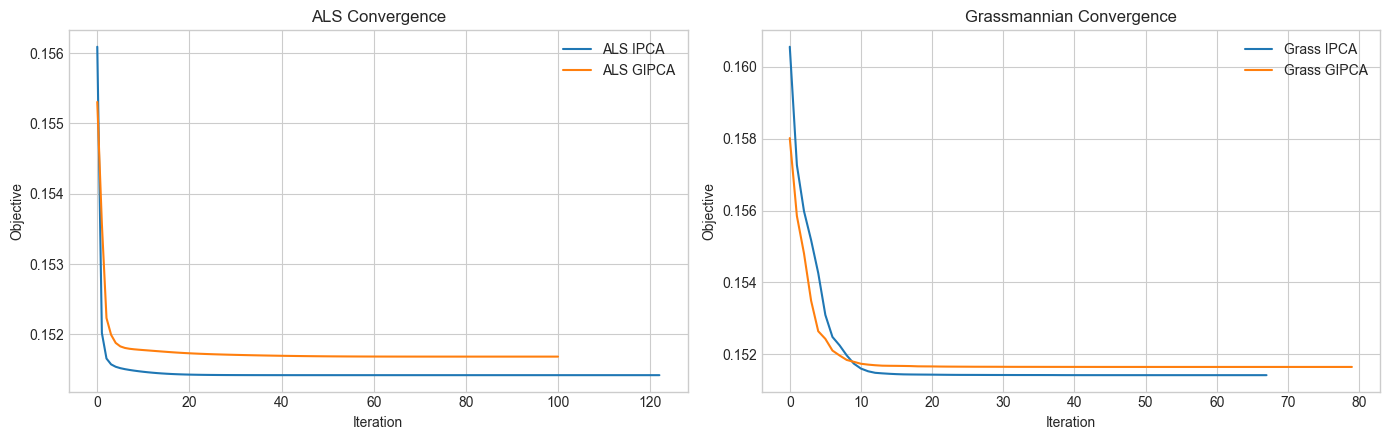

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(hist_als_ipca, label='ALS IPCA')
axes[0].plot(hist_als_gipca, label='ALS GIPCA')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Objective')
axes[0].set_title('ALS Convergence')
axes[0].legend()

axes[1].plot(hist_grass_ipca, label='Grass IPCA')
axes[1].plot(hist_grass_gipca, label='Grass GIPCA')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Objective')
axes[1].set_title('Grassmannian Convergence')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Gamma Comparison

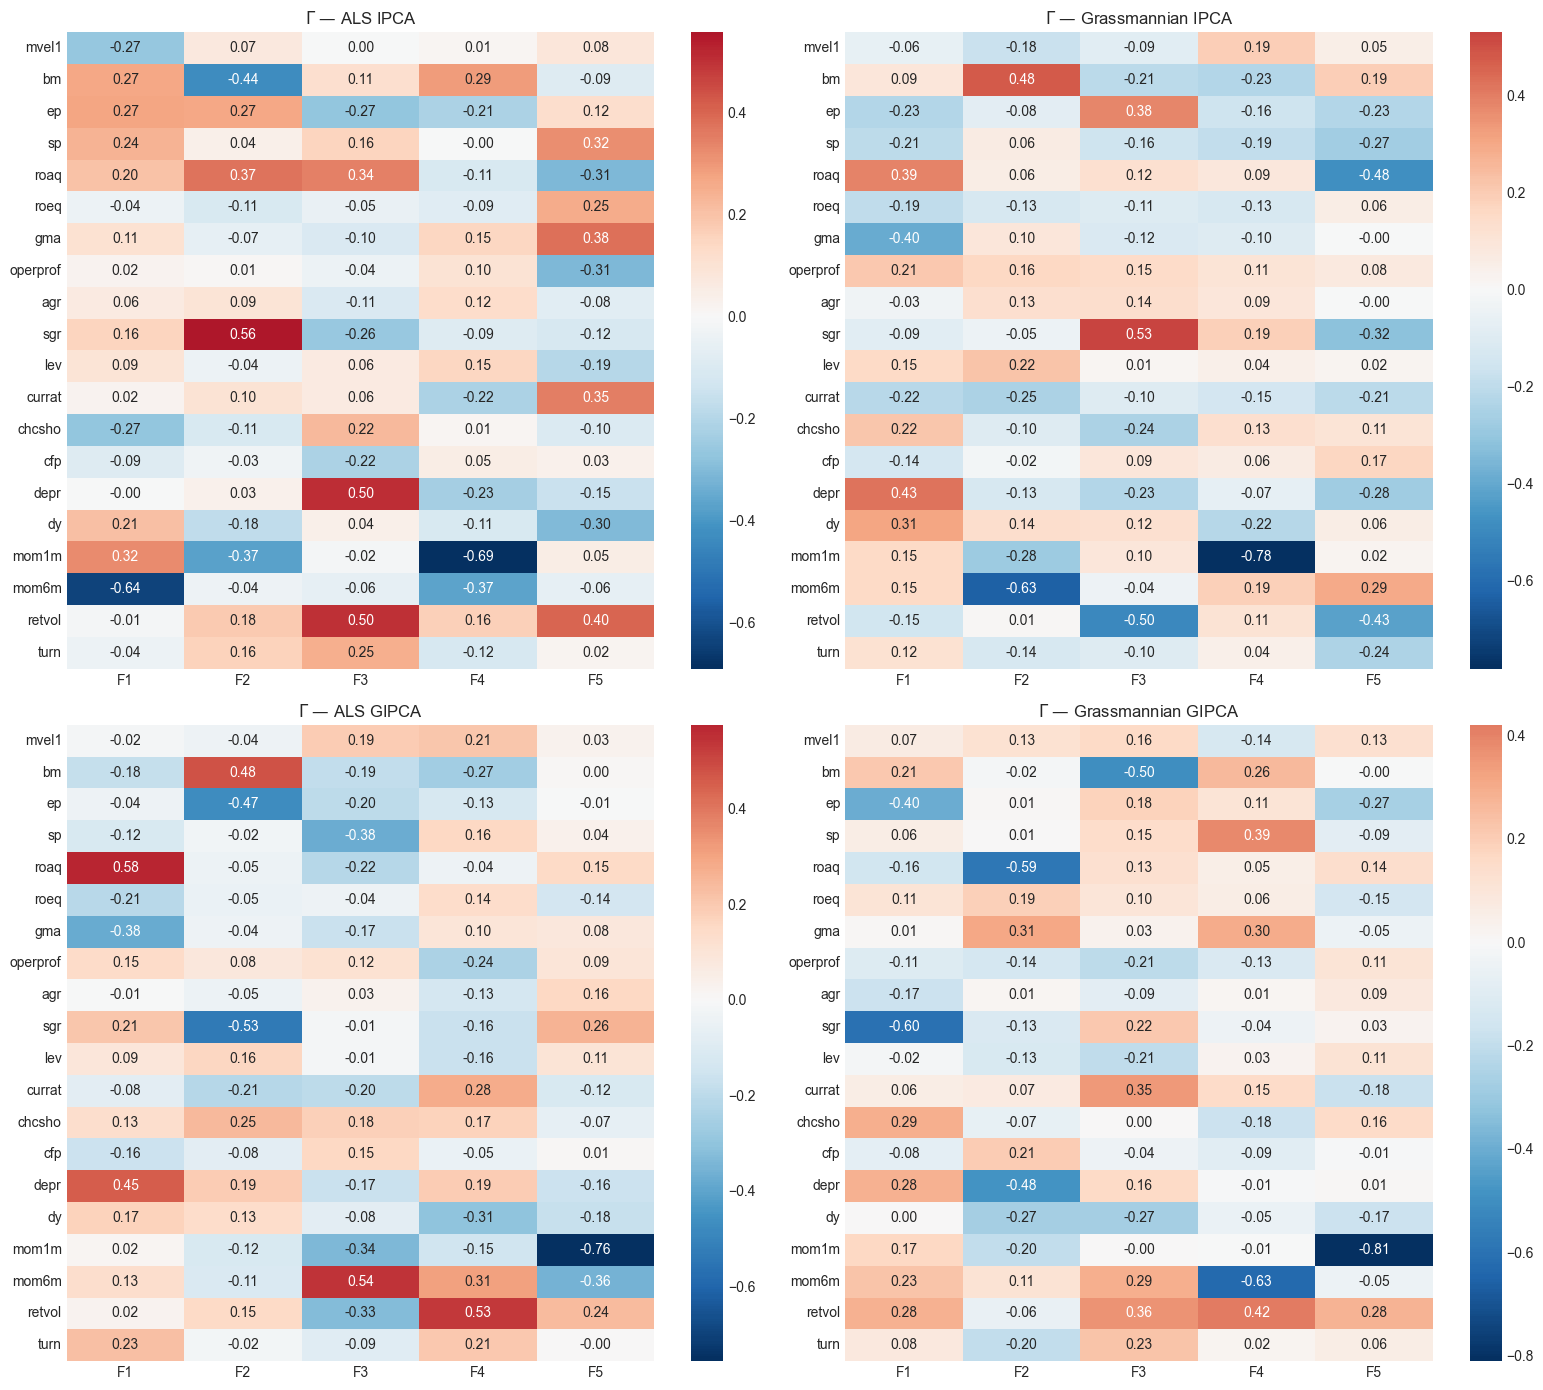

In [13]:
# Show all 20 characteristics in Gamma heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
gammas = [
    (Gamma_als_ipca, 'ALS IPCA'),
    (Gamma_grass_ipca, 'Grassmannian IPCA'),
    (Gamma_als_gipca, 'ALS GIPCA'),
    (Gamma_grass_gipca, 'Grassmannian GIPCA'),
]

for ax, (G, title) in zip(axes.flat, gammas):
    df_g = pd.DataFrame(G, index=char_names,
                        columns=[f'F{k+1}' for k in range(K)])
    sns.heatmap(df_g, cmap='RdBu_r', center=0, ax=ax, annot=True, fmt='.2f')
    ax.set_title(f'$\\Gamma$ \u2014 {title}')

plt.tight_layout()
plt.show()

## 6. Delta (GIPCA Macro Loadings)

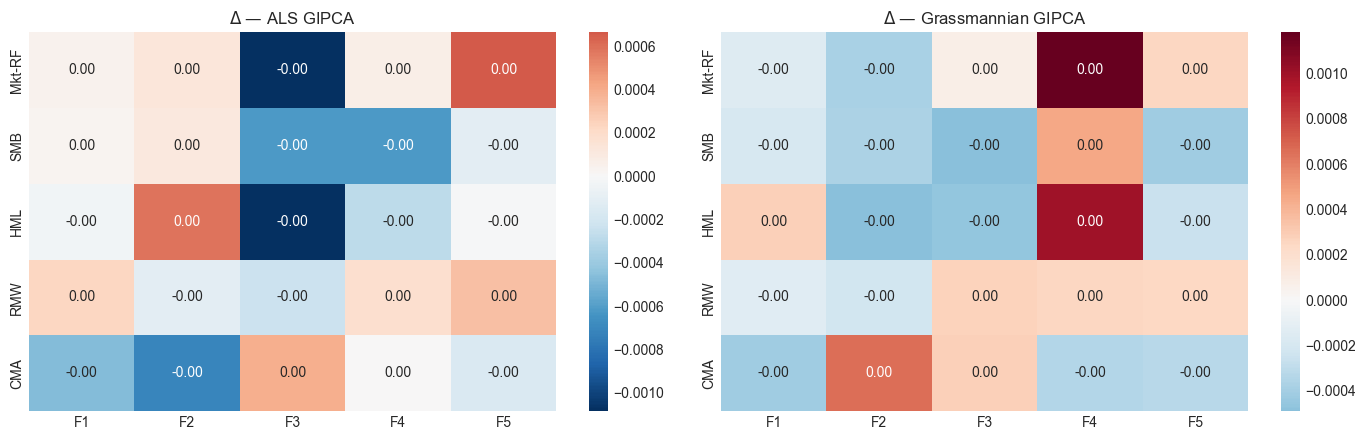

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, (Delta, title) in zip(axes, [
    (Delta_als_gipca, 'ALS GIPCA'),
    (Delta_grass_gipca, 'Grassmannian GIPCA'),
]):
    df_d = pd.DataFrame(Delta.T, index=macro_names,
                        columns=[f'F{k+1}' for k in range(K)])
    sns.heatmap(df_d, cmap='RdBu_r', center=0, ax=ax, annot=True, fmt='.2f')
    ax.set_title(f'$\\Delta$ \u2014 {title}')

plt.tight_layout()
plt.show()

## 7. Factor Time Series

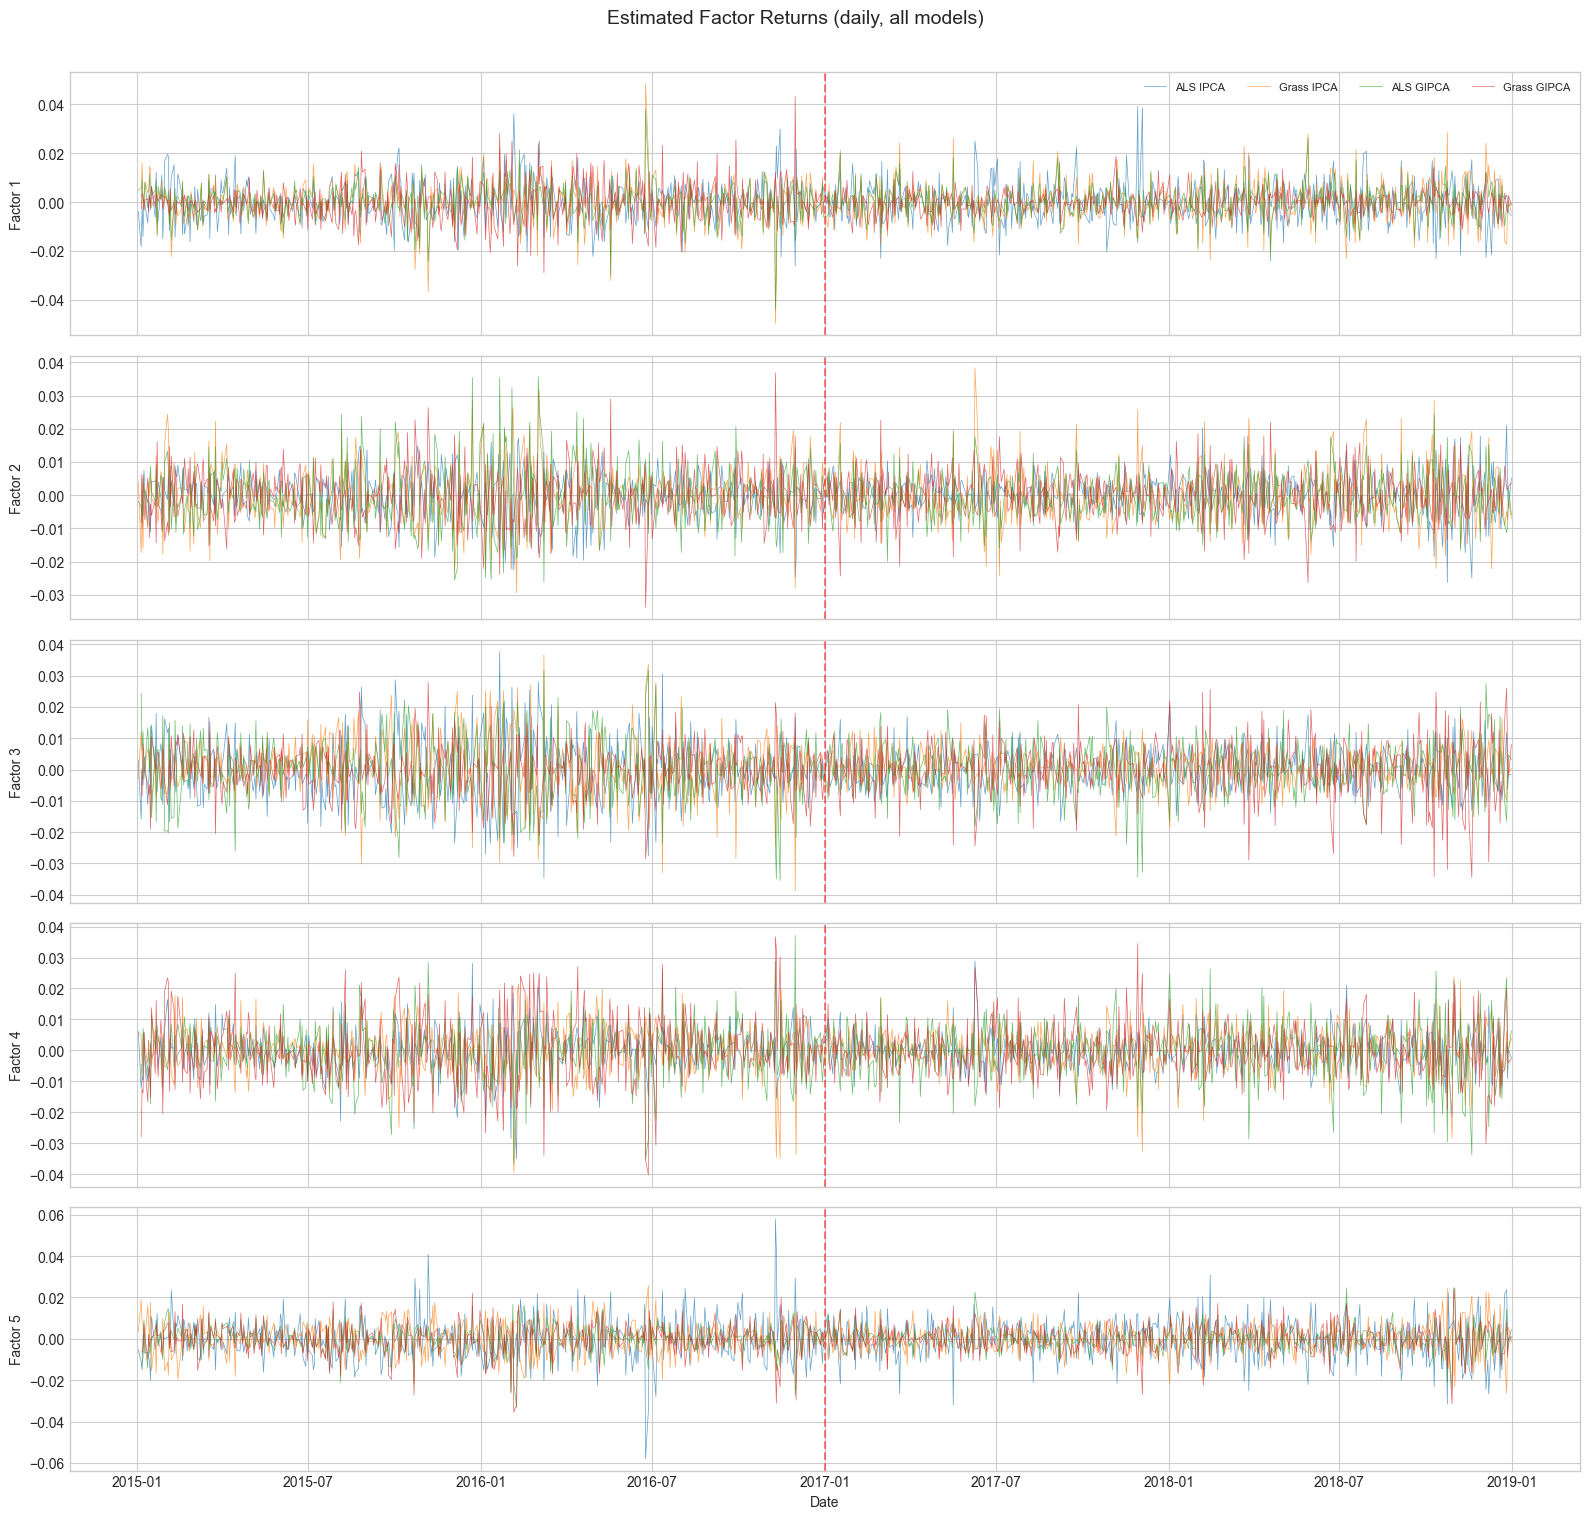

In [15]:
# Full-sample factors (IS train + OOS re-estimated)
all_f = {
    'ALS IPCA':   np.vstack([f_als_ipca, f_oos_als_ipca]),
    'Grass IPCA': np.vstack([f_grass_ipca, f_oos_grass_ipca]),
    'ALS GIPCA':  np.vstack([np.full((1, K), np.nan), f_als_gipca, f_oos_als_gipca]),
    'Grass GIPCA': np.vstack([np.full((1, K), np.nan), f_grass_gipca, f_oos_grass_gipca]),
}
all_dates = pd.DatetimeIndex(dates)
model_colors = {'ALS IPCA': 'C0', 'Grass IPCA': 'C1',
                'ALS GIPCA': 'C2', 'Grass GIPCA': 'C3'}

fig, axes = plt.subplots(K, 1, figsize=(16, 3 * K), sharex=True)

for k in range(K):
    for m_name in models:
        axes[k].plot(all_dates, all_f[m_name][:, k], linewidth=0.5,
                     color=model_colors[m_name], label=m_name, alpha=0.7)
    axes[k].axvline(pd.Timestamp('2017-01-01'), color='red', ls='--', alpha=0.5)
    axes[k].set_ylabel(f'Factor {k+1}')
    if k == 0:
        axes[k].legend(fontsize=8, ncol=4)

axes[-1].set_xlabel('Date')
fig.suptitle('Estimated Factor Returns (daily, all models)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 8. Portfolio Analysis (OOS)

In [16]:
def quintile_analysis(rets, Z, Gamma, signal_fn, ann_factor=252):
    """
    Sort stocks into quintiles by predicted expected return.
    signal_fn(t) -> (N,) predicted return vector for period t.
    Annualization: *ann_factor for returns, sqrt(ann_factor) for vol.
    """
    T_e, N_e = rets.shape
    n_q = 5
    q_rets = {q: [] for q in range(n_q)}

    for t in range(T_e):
        preds_t = signal_fn(t)
        rets_t = rets[t]
        valid = rets_t != 0
        if valid.sum() < n_q:
            continue

        preds_v = preds_t[valid]
        rets_v = rets_t[valid]
        breaks = np.percentile(preds_v, np.linspace(0, 100, n_q + 1))

        for q in range(n_q):
            if q == n_q - 1:
                mask_q = (preds_v >= breaks[q]) & (preds_v <= breaks[q + 1])
            else:
                mask_q = (preds_v >= breaks[q]) & (preds_v < breaks[q + 1])
            if mask_q.sum() > 0:
                q_rets[q].append(np.mean(rets_v[mask_q]))

    avg = [np.mean(q_rets[q]) * ann_factor for q in range(n_q)]
    std = [np.std(q_rets[q]) * np.sqrt(ann_factor) for q in range(n_q)]
    sharpe = [avg[q] / std[q] if std[q] > 0 else 0 for q in range(n_q)]

    ls = np.array(q_rets[n_q - 1]) - np.array(q_rets[0])
    ls_avg = np.mean(ls) * ann_factor
    ls_std = np.std(ls) * np.sqrt(ann_factor)
    ls_sr = ls_avg / ls_std if ls_std > 0 else 0

    return {'avg': avg, 'std': std, 'sharpe': sharpe,
            'ls_returns': ls, 'ls_avg': ls_avg, 'ls_std': ls_std, 'ls_sharpe': ls_sr}


# Signal functions — IPCA: constant mean; GIPCA: lagged macro
pf_als_ipca = quintile_analysis(
    test_rets, test_Z, Gamma_als_ipca,
    lambda t: test_Z[t] @ Gamma_als_ipca @ lam_als_ipca,
)
pf_grass_ipca = quintile_analysis(
    test_rets, test_Z, Gamma_grass_ipca,
    lambda t: test_Z[t] @ Gamma_grass_ipca @ lam_grass_ipca,
)
pf_als_gipca = quintile_analysis(
    test_rets, test_Z, Gamma_als_gipca,
    lambda t: test_Z[t] @ Gamma_als_gipca @ (Delta_als_gipca @ test_macro_lag[t]),
)
pf_grass_gipca = quintile_analysis(
    test_rets, test_Z, Gamma_grass_gipca,
    lambda t: test_Z[t] @ Gamma_grass_gipca @ (Delta_grass_gipca @ test_macro_lag[t]),
)

pf_results = {
    'ALS IPCA': pf_als_ipca, 'Grass IPCA': pf_grass_ipca,
    'ALS GIPCA': pf_als_gipca, 'Grass GIPCA': pf_grass_gipca,
}

for m in models:
    results[m]['ls_sharpe'] = pf_results[m]['ls_sharpe']

# --- Print portfolio table ---
print("Portfolio sorts: LAGGED macro for GIPCA, annualized x252 / sqrt(252)\n")
print(f"{'':12s}", end="")
for m in models:
    print(f"  {m:>16s}", end="")
print()

print(f"{'Quintile':12s}", end="")
for m in models:
    print(f"  {'Ret%':>7s} {'SR':>7s}", end="")
print()
print("-" * (12 + 18 * 4))

for q in range(5):
    print(f"Q{q+1:<11d}", end="")
    for m in models:
        print(f"  {pf_results[m]['avg'][q]*100:>6.2f}% {pf_results[m]['sharpe'][q]:>6.2f}", end="")
    print()

print("-" * (12 + 18 * 4))
print(f"{'L/S (Q5-Q1)':<12s}", end="")
for m in models:
    print(f"  {pf_results[m]['ls_avg']*100:>6.2f}% {pf_results[m]['ls_sharpe']:>6.2f}", end="")
print()

Portfolio sorts: LAGGED macro for GIPCA, annualized x252 / sqrt(252)

                      ALS IPCA        Grass IPCA         ALS GIPCA       Grass GIPCA
Quintile         Ret%      SR     Ret%      SR     Ret%      SR     Ret%      SR
------------------------------------------------------------------------------------
Q1              3.57%   0.23    3.53%   0.23   -4.39%  -0.31   -4.26%  -0.30
Q2              5.61%   0.41    5.60%   0.41    3.96%   0.32    3.94%   0.32
Q3              3.52%   0.28    3.51%   0.28    6.62%   0.55    6.42%   0.53
Q4              4.40%   0.38    4.42%   0.39    7.33%   0.59    7.38%   0.59
Q5              4.01%   0.35    4.06%   0.36    7.61%   0.54    7.65%   0.55
------------------------------------------------------------------------------------
L/S (Q5-Q1)     0.43%   0.04    0.54%   0.05   12.00%   1.08   11.91%   1.07


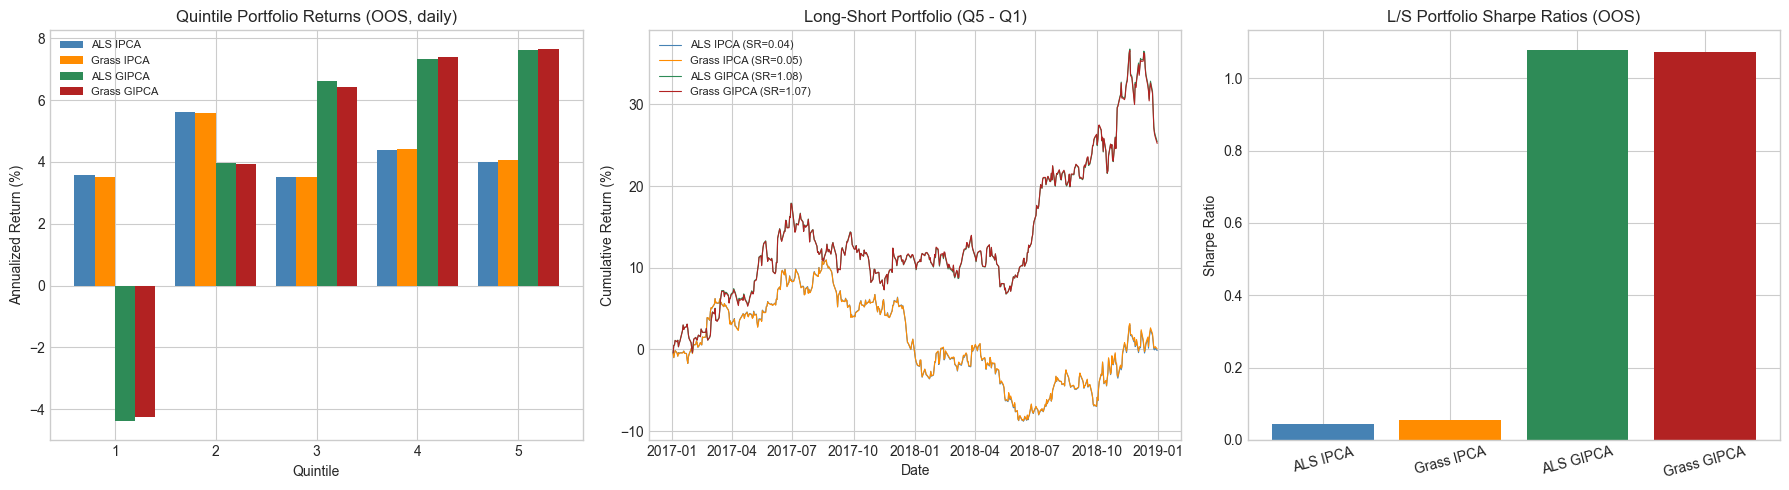

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick']

# --- Quintile returns ---
x = np.arange(5) + 1
n_m = len(models)
w = 0.8 / n_m
offsets = np.linspace(-(n_m - 1) * w / 2, (n_m - 1) * w / 2, n_m)

for i, m in enumerate(models):
    axes[0].bar(x + offsets[i], [r * 100 for r in pf_results[m]['avg']], w,
               label=m, color=colors[i])

axes[0].set_xlabel('Quintile')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].set_title('Quintile Portfolio Returns (OOS, daily)')
axes[0].set_xticks(x)
axes[0].legend(fontsize=8)

# --- Cumulative L/S ---
oos_dates_ls = all_dates[split_idx:split_idx + len(pf_als_ipca['ls_returns'])]
for i, m in enumerate(models):
    cum = np.cumprod(1 + pf_results[m]['ls_returns']) - 1
    axes[1].plot(oos_dates_ls, cum * 100, label=f"{m} (SR={pf_results[m]['ls_sharpe']:.2f})",
                color=colors[i], linewidth=0.8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Return (%)')
axes[1].set_title('Long-Short Portfolio (Q5 - Q1)')
axes[1].legend(fontsize=8)

# --- L/S Sharpe bar chart ---
ls_sharpes = [pf_results[m]['ls_sharpe'] for m in models]
axes[2].bar(range(len(models)), ls_sharpes, color=colors)
axes[2].set_xticks(range(len(models)))
axes[2].set_xticklabels(models, rotation=15)
axes[2].set_ylabel('Sharpe Ratio')
axes[2].set_title('L/S Portfolio Sharpe Ratios (OOS)')
axes[2].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 9. Final Summary

In [18]:
sup2 = chr(178)

summary_rows = [
    ('Final objective', [f"{results[m]['obj']:.4f}" for m in models]),
    ('IS Total R' + sup2 + ' (%)', [f"{results[m]['is_total']*100:.2f}" for m in models]),
    ('IS Predictive R' + sup2 + ' (%)', [f"{results[m]['is_pred']*100:.2f}" for m in models]),
    ('OOS Total R' + sup2 + ' (%)', [f"{results[m]['oos_total']*100:.2f}" for m in models]),
    ('OOS Predictive R' + sup2 + ' (%)', [f"{results[m]['oos_pred']*100:.2f}" for m in models]),
    ('L/S Sharpe (OOS)', [f"{results[m]['ls_sharpe']:.2f}" for m in models]),
    ('Iterations', [f"{results[m]['iters']}" for m in models]),
    ('Wall time (s)', [f"{results[m]['time']:.1f}" for m in models]),
    ('Parameters', [f"{results[m]['params']}" for m in models]),
    ('Predictive signal', ['mean(f)', 'mean(f)', "Delta' m_{t-1}", "Delta' m_{t-1}"]),
]

summary_df = pd.DataFrame(
    {row[0]: row[1] for row in summary_rows},
    index=models,
).T

print("\n" + "=" * 80)
print("    Daily IPCA vs GIPCA (S&P 500 / Sharadar / FF5 Macro): Final Comparison")
print("=" * 80)
print(summary_df.to_string())
print("=" * 80)
print("\nNotes:")
print(f"  - Universe: S&P 500 constituents (point-in-time), N={N}")
print(f"  - Frequency: daily, annualized x252 / sqrt(252)")
print(f"  - Characteristics: {L} (vs 95 monthly)")
print(f"  - K = {K} factors, R = {R} macro (FF5 daily)")
print(f"  - Train: {T_train} days, Test: {T_test} days, alpha = {ALPHA}")
print(f"  - IPCA predictive R{sup2} uses mean factor (lambda = mean(f_t))")
print(f"  - GIPCA predictive R{sup2} uses LAGGED macro: E_t[f_{{t+1}}] = Delta' m_t")
print(f"  - GIPCA has {K*R} extra params (K*R = {K}*{R}) for macro loadings")
print(f"  - Macro z-scored using training-period statistics only (no look-ahead)")


    Daily IPCA vs GIPCA (S&P 500 / Sharadar / FF5 Macro): Final Comparison
                      ALS IPCA Grass IPCA       ALS GIPCA     Grass GIPCA
Final objective         0.1514     0.1514          0.1517          0.1516
IS Total R² (%)          10.97      10.97           10.97           10.97
IS Predictive R² (%)      0.00       0.00            0.13            0.13
OOS Total R² (%)          8.57       8.57            8.57            8.56
OOS Predictive R² (%)    -0.00      -0.00           -0.07           -0.07
L/S Sharpe (OOS)          0.04       0.05            1.08            1.07
Iterations                 122         68             100              80
Wall time (s)             49.8       13.4            20.4            15.8
Parameters                 100        100             125             125
Predictive signal      mean(f)    mean(f)  Delta' m_{t-1}  Delta' m_{t-1}

Notes:
  - Universe: S&P 500 constituents (point-in-time), N=611
  - Frequency: daily, annualized x252 / sqrt